# Stage 2 ProxyOpt - SP Eval Analyzer & Visualizer

In [3]:
import numpy as np
import shutil
import os
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import cv2
import warnings

pd.set_option('display.max_rows', 500)
%cd /home/boat/proxyISP/pytorch-superpoint

/home/boat/proxyISP/pytorch-superpoint


/home/boat/miniconda3/envs/proxyopt/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


### Specify Evaluation Directories

In [4]:
eval_log_dirs = [
    "logs/eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200",
    "logs/eval_wl_v16.1_original",
]

In [5]:
objects = {}
for d in eval_log_dirs:
    objects[os.path.basename(d)] = (np.load(Path(d) / "predictions" / "result.npz"))
objects

{'eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200': NpzFile 'logs/eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200/predictions/result.npz' with keys: repeatability, localization_err, correctness, homography_thresh, mscore...,
 'eval_wl_v16.1_original': NpzFile 'logs/eval_wl_v16.1_original/predictions/result.npz' with keys: repeatability, localization_err, correctness, homography_thresh, mscore...}

### Single Value Metrics

In [6]:
for k in ["repeatability", "localization_err", "mscore", "mAP"]:
    print(f"{k}:")
    df = pd.DataFrame()
    for key, object in objects.items():
        value = object[k].mean(axis = 0)
        df[key] = np.array([value])
    display(df)

repeatability:


,eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200,eval_wl_v16.1_original
0,0.635336,0.596268


localization_err:


,eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200,eval_wl_v16.1_original
0,1.079448,1.155796


mscore:


,eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200,eval_wl_v16.1_original
0,0.348678,0.315628


mAP:


,eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200,eval_wl_v16.1_original
0,0.765758,0.736176


### Homography Correctness @k

homography correctness @1
 mean:
	eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200  mean 0.25833333333333336  | sum 31
	eval_wl_v16.1_original                                                                          mean 0.19166666666666668  | sum 23



,[0] _gradac8_158200,[1] _v16.1_original,is_diff
19,False,False,False
11,True,True,False


homography correctness @3
 mean:
	eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200  mean 0.625  | sum 75
	eval_wl_v16.1_original                                                                          mean 0.5083333333333333  | sum 61



,[0] _gradac8_158200,[1] _v16.1_original,is_diff
19,False,True,True
11,True,True,False


homography correctness @5
 mean:
	eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200  mean 0.7833333333333333  | sum 94
	eval_wl_v16.1_original                                                                          mean 0.675  | sum 81



...

,[0] _gradac8_158200,[1] _v16.1_original,is_diff
19,True,True,False
11,True,True,False


homography correctness @50
 mean:
	eval_wl_PRETRAINED_train_v16.1_RawEdgeContrastIndexTop100_lr0.0005_descLossOnly_gradac8_158200  mean 0.9583333333333334  | sum 115
	eval_wl_v16.1_original                                                                          mean 0.9416666666666667  | sum 113



,[0] _gradac8_158200,[1] _v16.1_original,is_diff
19,True,True,False
11,True,True,False


pair 19


/home/boat/miniconda3/envs/proxyopt/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


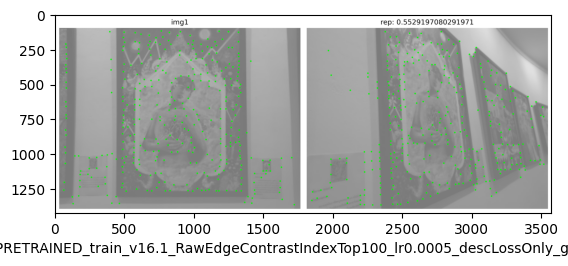

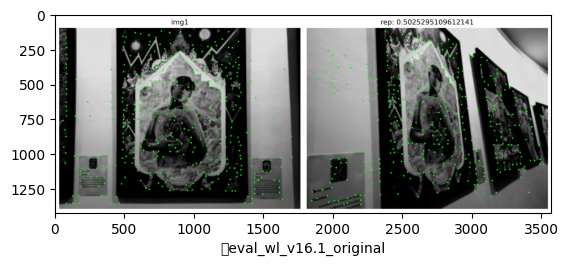


pair 11


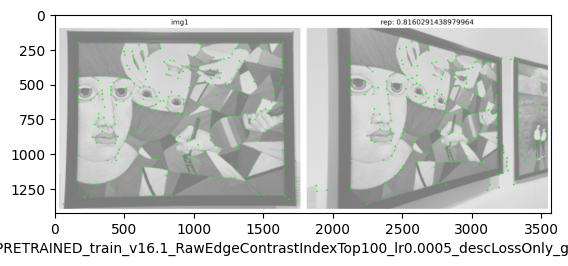

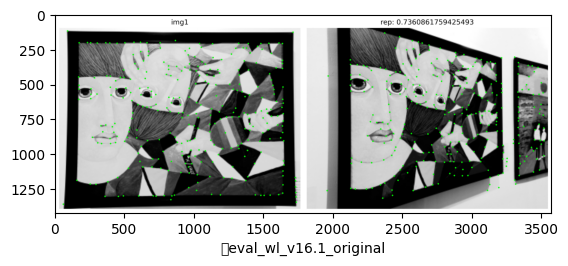

In [12]:
def show_homography_correctness(obj, only_diff = False, row_id_to_filter = None, plot_image = False, plot= "matching", single_table = False):
    first_name = next(iter(obj))
    thresh = obj[first_name]["homography_thresh"]
    longest_name_len = max([len(name) for name in obj])
    
    if single_table:
        df = pd.DataFrame()
        df_accum = pd.DataFrame()
        totals = []
        for k,t in enumerate(thresh):
            total = []
            for eval_id, (name, v) in enumerate(obj.items()):
                correctness_at_k = v["correctness"][:, k]
                total.append(correctness_at_k)
                # print("\t" + name," " * (longest_name_len - len(name)), "mean", correctness_at_k.mean(), " | sum", correctness_at_k.sum())
            # total = np.stack(total)
            totals.append(total)
        # Thresh,Eval,NumPair -> Numpairs, Eval, 1 (string of T, F of each threash)
        totals = np.stack(totals)
        totals = np.swapaxes(totals, 2, 0)
        totals = totals.tolist()
        TFs = []
        for p in totals:
            totals_ = []
            for ev in p:
                str_ = ""
                for t in ev:
                    str_ += ("T" if t else "F") + " "
                totals_.append(str_)
            TFs.append(totals_)
        # print(TFs)
        for k, tf in enumerate(TFs):
            for eval_id, (name, v) in enumerate(obj.items()):
                df.at[k, name] = tf[eval_id]
                # df_accum.at[k, "accum @k"]
        display(df)
            # df["is_diff"] = (total.sum(axis = 0) < total.shape[0]) & (total.sum(axis = 0) > 0)
         
    for k,t in enumerate(thresh):
        print(f"homography correctness @{t}\n mean:")
        df = pd.DataFrame()
        total = []
        for eval_id, (name, v) in enumerate(obj.items()):
            correctness_at_k = v["correctness"][:, k]
            df[f" [{eval_id}] {name[-15:]}"] = correctness_at_k
            total.append(correctness_at_k)
            print("\t" + name," " * (longest_name_len - len(name)), "mean", correctness_at_k.mean(), " | sum", correctness_at_k.sum())
        total = np.stack(total)
        df["is_diff"] = (total.sum(axis = 0) < total.shape[0]) & (total.sum(axis = 0) > 0)
        if row_id_to_filter is not None:
            df = df.loc[row_id_to_filter]
        if only_diff:
            df = df[df["is_diff"] == True]
        print()
        if not single_table:
            display(df)

    if plot_image and row_id_to_filter is None:
        warnings.warn("Image will not be plotted, row_id_to_filter is None, plotting all images will slow down the notebook")
    if plot_image and row_id_to_filter is not None:
        for index, row in df.iterrows():
            print(f"pair {index}")
            for d in eval_log_dirs:
                base_path = Path(d) / "predictions"
                if plot == "matching":
                    image_filepath = base_path / "matching" / f"{index}m.png"
                else:
                    image_filepath = base_path / plot / f"{index}.png"
                image_image = cv2.imread(str(image_filepath))
                plt.imshow(image_image[:,:,::-1])
                plt.xlabel(f"\t{os.path.basename(d)}")
                plt.show()
            print("")

only_diff = False
row_id_to_filter =  [19,11]
# row_id_to_filter = None
plot_image = True
single_table = False
plot = "repeatibility3"

show_homography_correctness(objects, only_diff = only_diff, row_id_to_filter = row_id_to_filter, plot_image = plot_image, plot=plot, single_table=single_table)

# Optimized Hype Visualize

In [1]:
# plot_original_hype = True
# limit = 10
# config_path = "../ProxyOpt/train_configs/v16.1.yaml"
# images_path = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/low-light"
# hype_checkpoint_paths = [
#     "logs_backup/train_v16.1_lowlight_lr0.0005_gradac8/proxyopt_checkpoints/checkpoint_40000.pkl"
# ]

plot_original_hype = True
limit = 2
config_path = "../ProxyOpt/train_configs/v16.1.yaml"
images_path = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/sunlit"
hype_checkpoint_paths = [
    "/home/boat/proxyISP/DGC-Net/proxydgc_logs/train_bestRawEdgeContrastTop100/checkpoints/checkpoint_180000.pkl"
]

/home/boat/miniconda3/envs/proxyopt/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/boat/proxyISP/pytorch-superpoint


[06-24 14:46:05] ProxyISPDataset.py INFO - Initializing ProxyISPDataset Dataset...
[06-24 14:46:05] ProxyISPDataset.py INFO - target image provided in additional_conf, using it as raw image
[06-24 14:46:05] ProxyISPDataset.py INFO - raw image len188
[06-24 14:46:05] ProxyISPDataset.py INFO - total raw images: 188
[06-24 14:46:05] ProxyISPDataset.py INFO - hyperp length: 20000
[06-24 14:46:05] ProxyISPDataset.py INFO - num_hyperp x num_image: 3760000
[06-24 14:46:06] ProxyISPDataset.py INFO - total dataset length: 3760000


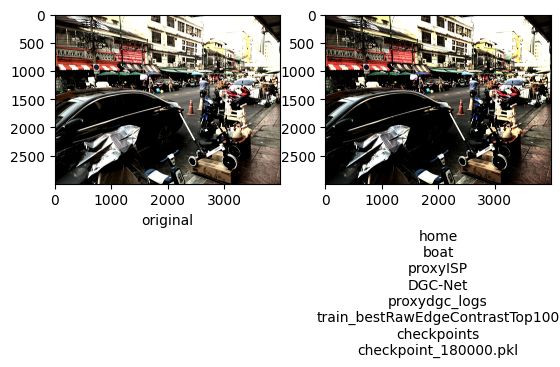

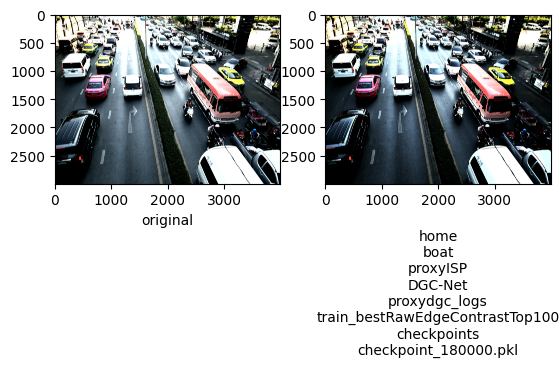

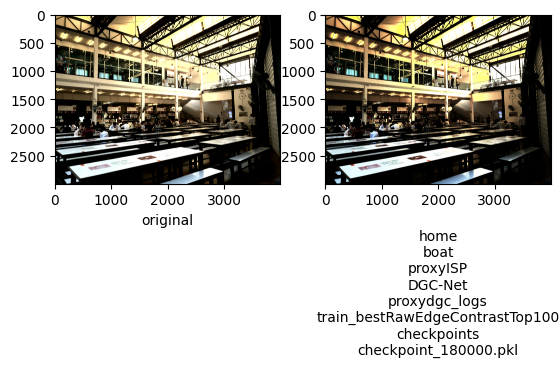

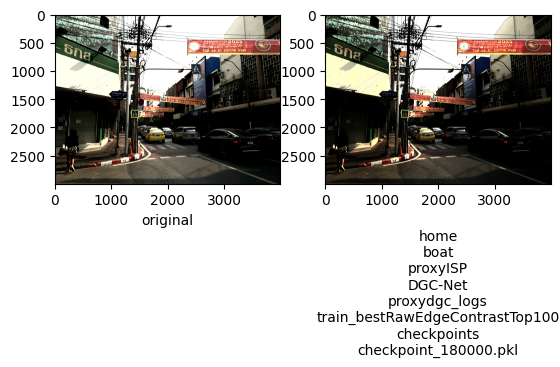

KeyboardInterrupt: 

In [2]:
%cd /home/boat/proxyISP/pytorch-superpoint

import sys
sys.path.insert(0, "../ProxyOpt/")
sys.path.insert(0, "../fast-openISP/")
import yaml
import rawpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import io
from contextlib import redirect_stdout
import os
from ISP_tools.ProxyISPDataset import ProxyISPDataset, EXPERIMENT_OUTPUT_PATH

isp_hyps = [np.load(p, allow_pickle = True)['proxy_hype'] for p in hype_checkpoint_paths]

with open(config_path, "r") as f:
    yaml_dict = yaml.safe_load(f)

config = yaml_dict["config"]
openisp_config = yaml_dict["openisp_config"]
hyp_setting = yaml_dict["hyp_setting"]

additional_conf = {
        # "target_image": ["/home/boat/proxyISP/data/s21fe_dataset/20240115_123915.dng"],
        # "target_image": ["/home/boat/proxyISP/data/s21fe_dataset/20240117_182706.dng"],
        "proxyopt_base_path": "/home/boat/proxyISP/ProxyOpt/"
}

raw_images = [str(p) for p in Path(images_path).rglob("*.dng")]
additional_conf["target_image"] = raw_images

dataset = ProxyISPDataset(config, openisp_config, hyp_setting, additional_conf)

total_figure_per_image = len(isp_hyps) + plot_original_hype
with redirect_stdout(io.StringIO()):
    for image_path in dataset.raw_img[:10]:
        print("image : ", os.path.basename(image_path))
        bayer = rawpy.imread(image_path).raw_image
        if plot_original_hype:
            plt.subplot(1, total_figure_per_image, 1)
            processed = dataset.process_raw(bayer, original_hyp = True)
            plt.imshow(processed)
            plt.xlabel("original")
        for k, isp_hyp in enumerate(isp_hyps):
            isp_hyp = dataset.denormalize_hyp(isp_hyp)
            processed = dataset.process_raw(bayer, isp_hyp,original_hyp = False)
            plt.subplot(1, total_figure_per_image, k + total_figure_per_image)
            plt.imshow(processed)
            plt.xlabel(hype_checkpoint_paths[k].replace("/", "\n"))
        plt.show()

# Compare Value

In [17]:
import pandas as pd
original_hype = dataset.get_original_hyp(False, False)
orig_hype_dict = dataset.get_named_hyp(original_hype)
optimized_hype_dicts = [dataset.get_named_hyp(dataset.denormalize_hyp(h)) for h in isp_hyps]
print("orig_hype_dict",orig_hype_dict)
print("optimized_hype_dicts", optimized_hype_dicts)

# Create DataFrame and transpose to vertical
df = pd.DataFrame({'Original': orig_hype_dict})
for i, opt in enumerate(optimized_hype_dicts):
    df[f'Optimized {i+1}'] = pd.Series(opt)

# Optional: Highlight changed cells
def highlight_changes(val, col):
    try:
        if col != 'Original' and val != df['Original'][col_name]:
            return 'background-color: lightyellow'
    except:
        pass
    return ''

# Apply the highlight
styled_df = df.style.apply(lambda col: [
    'background-color: lightyellow' if col.name != 'Original' and v != df['Original'].get(col.name) else ''
    for col_name, v in col.items()
], axis=0)

# Show or export
styled_df.set_caption("Vertical Comparison: Original vs Optimized ISP Hyperparameters")



orig_hype_dict {'cfa-mode': 'malvar', 'gac-gain': 720, 'gac-gamma': 0.8, 'bcc-brightness_offset': 0, 'bcc-contrast_gain': 512, 'bnfcv-d': 1, 'bnfcv-sigma_color': 10, 'bnfcv-sigma_space': 10, 'eeh-edge_gain': 1, 'eeh-flat_threshold': 1, 'eeh-edge_threshold': 8, 'eeh-delta_threshold': 64}
optimized_hype_dicts [{'cfa-mode': 'malvar', 'gac-gain': 419, 'gac-gamma': 1.0120095945894718, 'bcc-brightness_offset': 143, 'bcc-contrast_gain': 220, 'bnfcv-d': 1, 'bnfcv-sigma_color': 1, 'bnfcv-sigma_space': 1, 'eeh-edge_gain': 13, 'eeh-flat_threshold': 1, 'eeh-edge_threshold': 4, 'eeh-delta_threshold': 6}]


,cfa-mode,gac-gain,gac-gamma,bcc-brightness_offset,bcc-contrast_gain,bnfcv-d,bnfcv-sigma_color,bnfcv-sigma_space,eeh-edge_gain,eeh-flat_threshold,eeh-edge_threshold,eeh-delta_threshold
Original,malvar,720,0.800000,0,512,1,10,10,1,1,8,64
Optimized 1,malvar,419,1.012010,143,220,1,1,1,13,1,4,6


[1, 0, 419, 1.0120095945894718, 143, 220, 1, 1, 1, 13, 1, 4, 6]